# 03 – SARIMA Model

**PM2.5 Time Series: Factor Analysis & SARIMA**  
Notebook này triển khai **Step 3 – SARIMA** dựa trên logic trong `src/sarima_model.py`.

## Mục tiêu

- Đọc `data/processed/fa_data.csv` (đã có PM2.5 và Factor1, Factor2, Factor3).
- Gộp dữ liệu theo **ngày** (trung bình theo ngày) để dùng SARIMA theo ngày, mùa 7 ngày.
- **Phân rã chuỗi** (Trend, Seasonal, Residual) và kiểm định **stationarity** (ADF).
- Vẽ **ACF/PACF** để hỗ trợ chọn tham số.
- Dùng **auto_arima** (pmdarima) với biến ngoại sinh (Factor1–3), chia train/test, fit và lưu mô hình.

## Các lệnh / bước chính

| Bước | Lệnh / Hàm | Mô tả ngắn |
|------|------------|------------|
| 1 | `pd.read_csv(..., parse_dates=True)` | Đọc fa_data.csv, index là datetime |
| 2 | `df.resample("D").mean()` | Gộp theo ngày (daily baseline) |
| 3 | `seasonal_decompose(..., period=7)` | Phân rã: Observed = Trend + Seasonal + Residual |
| 4 | `adfuller(series)` | Kiểm định ADF (chuỗi dừng hay không) |
| 5 | `plot_acf`, `plot_pacf` | ACF/PACF để gợi ý p, q |
| 6 | Train/test split | 80% train, 20% test (theo thời gian) |
| 7 | `auto_arima(..., X=exog, seasonal=True, m=7)` | Tìm (p,d,q)(P,D,Q)m và fit |
| 8 | `joblib.dump(...)` | Lưu mô hình + exog_cols vào data/processed |

## Điều kiện trước khi chạy

- Đã có `data/processed/fa_data.csv` (tạo từ Step 2 / `02_factor_analysis.ipynb` hoặc `python src/factor_analysis.py`).

## Thiết lập môi trường

- Thêm project root vào `sys.path` để có thể `import` từ `src`.
- Định nghĩa thư mục: `PROCESSED_DIR` (fa_data), `ARIMA_FIG` (figures), `TABLES_DIR` (bảng ADF).
- Các thư viện: `pandas`, `matplotlib`, `statsmodels` (decompose, adfuller, acf/pacf), `pmdarima` (auto_arima), `joblib` (lưu mô hình).

In [1]:
# Thiết lập môi trường
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from pmdarima import auto_arima
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Project root (chạy từ notebooks/ hoặc từ root)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

PROCESSED_DIR = ROOT / "data" / "processed"
ARIMA_FIG = ROOT / "reports" / "figures" / "03_sarima"
TABLES_DIR = ROOT / "reports" / "tables"

for p in [PROCESSED_DIR, ARIMA_FIG, TABLES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300
pd.set_option("display.max_columns", 50)

# Tên cột biến ngoại sinh (đúng với fa_data)
FACTOR_COLS = ["Factor1", "Factor2", "Factor3"]

print("ROOT:", ROOT)
print("fa_data:", PROCESSED_DIR / "fa_data.csv")
print("Figures:", ARIMA_FIG)

ROOT: E:\myself\GITHUB\pm25_sarima_project
fa_data: E:\myself\GITHUB\pm25_sarima_project\data\processed\fa_data.csv
Figures: E:\myself\GITHUB\pm25_sarima_project\reports\figures\03_sarima


## 1. Đọc dữ liệu fa_data

**Lệnh:** `pd.read_csv(path, index_col=0, parse_dates=True)`  
- `index_col=0`: cột đầu tiên là index (datetime).  
- `parse_dates=True`: chuyển index thành kiểu datetime.  

File `fa_data.csv` chứa dữ liệu theo **giờ**, gồm PM2.5 và các nhân tố Factor1, Factor2, Factor3 (từ Factor Analysis).

In [2]:
fa_path = PROCESSED_DIR / "fa_data.csv"
if not fa_path.exists():
    raise FileNotFoundError(f"Thiếu {fa_path}. Hãy chạy Step 2 (Factor Analysis) trước.")

df = pd.read_csv(fa_path, index_col=0, parse_dates=True)

print("Shape:", df.shape)
print("Index:", df.index.min(), "->", df.index.max())
print("Cột:", list(df.columns))
df.head(10)

Shape: (35064, 17)
Index: 2013-03-01 00:00:00 -> 2017-02-28 23:00:00
Cột: ['No', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station', 'Factor1', 'Factor2', 'Factor3']


,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,Factor1,Factor2,Factor3
datetime,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,1,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan,-0.811936,-1.630062,1.664840
2013-03-01 01:00:00,2,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan,-0.812264,-1.657208,1.839390
2013-03-01 02:00:00,3,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan,-0.775855,-1.765657,2.229951
2013-03-01 03:00:00,4,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan,-0.993166,-1.553157,0.863202
2013-03-01 04:00:00,5,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan,-1.163871,-1.447068,0.415375
2013-03-01 05:00:00,6,3.0,6.0,6.0,14.0,400.0,71.0,-2.2,1025.6,-19.6,0.0,N,3.7,Guanyuan,-1.000919,-1.660680,1.287501
2013-03-01 06:00:00,7,6.0,6.0,6.0,20.0,400.0,66.0,-2.6,1026.5,-19.1,0.0,NNE,2.5,Guanyuan,-1.089346,-1.559290,0.589480
2013-03-01 07:00:00,8,3.0,3.0,7.0,26.0,400.0,61.0,-1.6,1027.4,-19.1,0.0,NNW,3.8,Guanyuan,-0.951687,-1.719771,1.181526
2013-03-01 08:00:00,9,3.0,6.0,9.0,37.0,500.0,50.0,0.1,1028.3,-19.2,0.0,NNW,4.1,Guanyuan,-0.818256,-1.759828,1.213181


## 2. Gộp theo ngày (aggregate to daily)

**Lệnh:** `df[numeric_cols].resample("D").mean()`  
- Chỉ lấy cột số, gộp theo **ngày** ("D"), lấy **trung bình** mỗi ngày.  
- Mục đích: SARIMA baseline dùng **daily** data, chu kỳ mùa **m = 7** (tuần).  
- Sau bước này mỗi dòng là một ngày.

In [3]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
daily = df[numeric_cols].resample("D").mean()
daily = daily.dropna(how="all")

print("Shape daily:", daily.shape)
print("Số ngày:", len(daily))
if "PM2.5" not in daily.columns:
    raise ValueError("Cột PM2.5 không có trong fa_data")

pm25 = daily["PM2.5"]
daily.head(10)

Shape daily: (1461, 15)
Số ngày: 1461


,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,Factor1,Factor2,Factor3
datetime,,,,,,,,,,,,,,,
2013-03-01,12.5,7.541667,11.666667,8.500000,28.500000,400.000000,63.166667,1.391667,1026.875000,-18.745833,0.0,3.254167,-0.914368,-1.545788,0.951963
2013-03-02,36.5,26.375000,34.875000,28.041667,62.854167,841.583333,35.166667,0.616667,1026.850000,-15.937500,0.0,1.479167,-0.431125,-1.374094,-0.201946
2013-03-03,60.5,81.500000,119.083333,69.208333,96.458333,1966.458333,16.500000,5.566667,1014.608333,-12.316667,0.0,1.658333,1.084973,-0.867064,0.086458
2013-03-04,84.5,18.250000,41.958333,20.208333,51.333333,625.000000,54.500000,9.962500,1017.650000,-11.683333,0.0,2.404167,-0.445892,-0.789041,0.457027
2013-03-05,108.5,141.166667,163.708333,83.375000,134.750000,2483.083333,78.791667,6.291667,1010.900000,-7.525000,0.0,1.129167,1.978745,-0.382231,0.263186
2013-03-06,132.5,205.583333,229.750000,126.812500,154.958333,3378.791667,28.416667,7.183333,1007.483333,-4.216667,0.0,1.483333,3.185003,-0.381817,0.404679
2013-03-07,156.5,248.000000,280.125000,98.708333,161.375000,3949.666667,46.666667,9.287500,1002.320833,-2.033333,0.0,1.558333,3.283481,0.050679,0.385442
2013-03-08,180.5,209.958333,249.500000,63.980933,139.753400,3208.062500,106.000000,9.612500,999.475000,-1.150000,0.0,1.637500,2.486149,0.350416,0.655597
2013-03-09,204.5,51.750000,240.458333,36.708333,49.833333,1024.833333,96.916667,6.983333,1004.391667,-10.162500,0.0,3.391667,1.003026,-0.322184,1.811271


## 3. Phân rã chuỗi thời gian (Decomposition)

**Lệnh:** `seasonal_decompose(series, model="additive", period=7, extrapolate_trend="freq")`  
- **model="additive"**: Observed = Trend + Seasonal + Residual.  
- **period=7**: mùa 7 ngày (tuần).  
- **extrapolate_trend="freq"**: ngoại suy trend ở hai đầu để tránh NaN.  

Kết quả: 4 chuỗi — Observed, Trend, Seasonal, Residual. Lưu figure vào `reports/figures/03_arima/decomposition.png`.

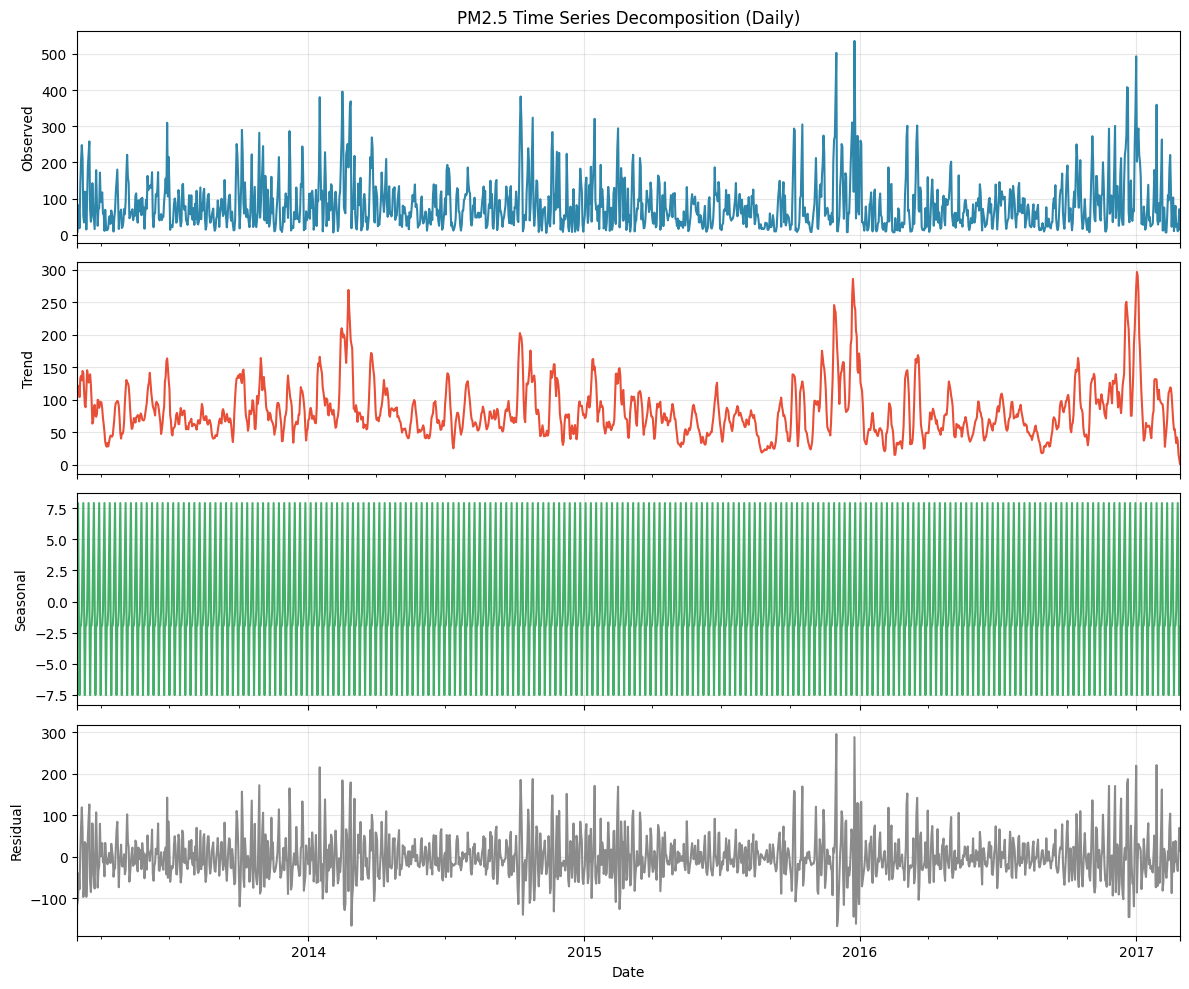

Đã lưu: E:\myself\GITHUB\pm25_sarima_project\reports\figures\03_sarima\decomposition.png


In [4]:
PERIOD = 7  # chu kỳ mùa (ngày)
decomp = seasonal_decompose(pm25, model="additive", period=PERIOD, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomp.observed.plot(ax=axes[0], color="#2E86AB")
axes[0].set_ylabel("Observed")
axes[0].set_title("PM2.5 Time Series Decomposition (Daily)")
decomp.trend.plot(ax=axes[1], color="#E94F37")
axes[1].set_ylabel("Trend")
decomp.seasonal.plot(ax=axes[2], color="#44AF69")
axes[2].set_ylabel("Seasonal")
decomp.resid.plot(ax=axes[3], color="#8B8B8B")
axes[3].set_ylabel("Residual")
axes[3].set_xlabel("Date")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()

decomp_path = ARIMA_FIG / "decomposition.png"
plt.savefig(decomp_path, dpi=300, bbox_inches="tight")
plt.show()
print("Đã lưu:", decomp_path)

## 4. Kiểm định ADF (Augmented Dickey–Fuller)

**Lệnh:** `adfuller(series.dropna(), autolag="AIC")`  
- Kiểm định **stationarity**: H0 = chuỗi không dừng.  
- **p-value < 0.05** → bác bỏ H0 → chuỗi **dừng** (stationary).  
- **autolag="AIC"**: tự chọn số lag tối ưu theo AIC.  

Kết quả lưu vào `reports/tables/adf_results.txt` và `adf_results.csv`.

In [5]:
adf_result = adfuller(pm25.dropna(), autolag="AIC")

adf_stats = {
    "adf_statistic": adf_result[0],
    "p_value": adf_result[1],
    "usedlag": adf_result[2],
    "nobs": adf_result[3],
    "critical_values": adf_result[4],
    "icbest": adf_result[5],
}

print("ADF Statistic:", f"{adf_stats['adf_statistic']:.6f}")
print("p-value:", f"{adf_stats['p_value']:.6f}")
print("Used lag:", adf_stats["usedlag"])
print("Critical values:", adf_stats["critical_values"])
conclusion = "Chuỗi DỪNG (stationary)" if adf_stats["p_value"] < 0.05 else "Chuỗi KHÔNG dừng (non-stationary)"
print("Kết luận:", conclusion)

# Lưu báo cáo text
lines = [
    "Augmented Dickey-Fuller Test Results",
    "=" * 40,
    f"ADF Statistic: {adf_stats['adf_statistic']:.6f}",
    f"p-value:       {adf_stats['p_value']:.6f}",
    f"Used lag:      {adf_stats['usedlag']}",
    f"N observations: {adf_stats['nobs']}",
    "Critical values:",
]
for k, v in adf_stats["critical_values"].items():
    lines.append(f"  {k}: {v:.3f}")
lines.append("")
lines.append("Conclusion: Series is STATIONARY" if adf_stats["p_value"] < 0.05 else "Conclusion: Series is NON-STATIONARY")

txt_path = TABLES_DIR / "adf_results.txt"
with open(txt_path, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))
csv_path = TABLES_DIR / "adf_results.csv"
pd.DataFrame([{"adf_statistic": adf_stats["adf_statistic"], "p_value": adf_stats["p_value"]}]).to_csv(csv_path, index=False)
print("Đã lưu:", txt_path, csv_path)

ADF Statistic: -20.993873
p-value: 0.000000
Used lag: 1
Critical values: {'1%': np.float64(-3.4348399537053482), '5%': np.float64(-2.8635230163107837), '10%': np.float64(-2.5678257404326903)}
Kết luận: Chuỗi DỪNG (stationary)
Đã lưu: E:\myself\GITHUB\pm25_sarima_project\reports\tables\adf_results.txt E:\myself\GITHUB\pm25_sarima_project\reports\tables\adf_results.csv


## 5. ACF và PACF

**Lệnh:** `plot_acf(series, lags=...)`, `plot_pacf(series, lags=..., method="ywm")`  
- **ACF** (Autocorrelation): tương quan của chuỗi với chính nó tại các độ trễ → gợi ý bậc **q** (MA).  
- **PACF** (Partial ACF): tương quan riêng phần → gợi ý bậc **p** (AR).  
- **method="ywm"**: ước lượng PACF (Yule–Walker modified).  

Lưu figure vào `reports/figures/03_arima/acf_pacf.png`.

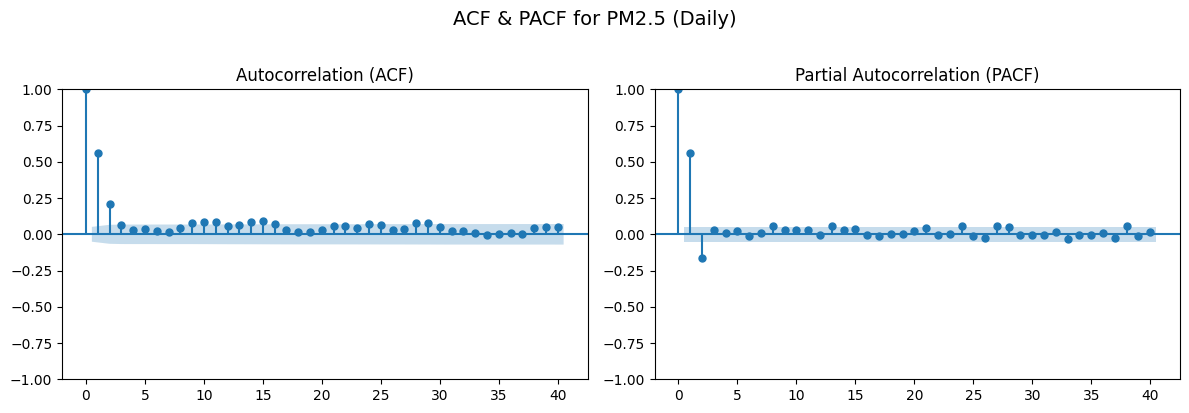

Đã lưu: E:\myself\GITHUB\pm25_sarima_project\reports\figures\03_sarima\acf_pacf.png


In [6]:
LAGS = 40
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(pm25.dropna(), lags=LAGS, ax=axes[0])
axes[0].set_title("Autocorrelation (ACF)")
plot_pacf(pm25.dropna(), lags=LAGS, ax=axes[1], method="ywm")
axes[1].set_title("Partial Autocorrelation (PACF)")
plt.suptitle("ACF & PACF for PM2.5 (Daily)", fontsize=14, y=1.02)
plt.tight_layout()

acf_path = ARIMA_FIG / "acf_pacf.png"
plt.savefig(acf_path, dpi=300, bbox_inches="tight")
plt.show()
print("Đã lưu:", acf_path)

## 6. Chia train / test

**Lệnh:** Chia theo **thời gian** (không xáo trộn): 80% đầu làm train, 20% cuối làm test.  
- `y_train`, `y_test`: chuỗi PM2.5.  
- `exog_train`, `exog_test`: DataFrame các cột Factor1, Factor2, Factor3 (nếu có) dùng làm biến ngoại sinh cho SARIMAX.

In [7]:
TEST_RATIO = 0.2
n = len(daily)
split_idx = int(n * (1 - TEST_RATIO))
train_df = daily.iloc[:split_idx]
test_df = daily.iloc[split_idx:]

y_train = train_df["PM2.5"]
y_test = test_df["PM2.5"]

exog_cols = [c for c in FACTOR_COLS if c in daily.columns]
exog_train = train_df[exog_cols] if exog_cols else None
exog_test = test_df[exog_cols] if exog_cols else None

print("Train: ", len(y_train), " ngày")
print("Test:  ", len(y_test), " ngày")
print("Biến ngoại sinh (exog):", exog_cols if exog_cols else "Không dùng")

Train:  1168  ngày
Test:   293  ngày
Biến ngoại sinh (exog): ['Factor1', 'Factor2', 'Factor3']


## 7. Auto ARIMA với biến ngoại sinh

**Lệnh:** `auto_arima(y_train, X=exog_train.values, seasonal=True, m=7, stepwise=True, ...)`  
- **X**: ma trận biến ngoại sinh (Factor1, Factor2, Factor3) — phải cùng số hàng với `y_train`.  
- **seasonal=True, m=7**: SARIMA với mùa 7 ngày.  
- **stepwise=True**: tìm (p,d,q)(P,D,Q) nhanh hơn.  
- **suppress_warnings=True, error_action="ignore"**: giảm log khi thử nhiều mô hình.  

Kết quả: mô hình ARIMA đã fit (order + seasonal_order). Có thể mất vài phút.

In [8]:
exog_arr = exog_train.values if exog_train is not None else None

model = auto_arima(
    y_train,
    X=exog_arr,
    seasonal=True,
    m=PERIOD,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=False,
)

print("Order (p,d,q):", model.order)
print("Seasonal order (P,D,Q,m):", model.seasonal_order)
print("Tóm tắt mô hình:")
model.summary()

Order (p,d,q): (2, 1, 1)
Seasonal order (P,D,Q,m): (1, 0, 0, 7)
Tóm tắt mô hình:


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                 1168
Model:             SARIMAX(2, 1, 1)x(1, 0, [], 7)   Log Likelihood               -5411.721
Date:                            Sat, 14 Mar 2026   AIC                          10839.443
Time:                                    08:25:54   BIC                          10879.941
Sample:                                03-01-2013   HQIC                         10854.719
                                     - 05-11-2016                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            65.7830      0.933     70.484      0.000      63.954      67.612
x2            25.1043      3.438      7.303      0.000      18.367      31.842
x3            -6.5704      1.599     -4.110      0.000      -9.704      -3.437
ar.L1          0.5878      0.029     20.089      0.000       0.530       0.645
ar.L2         -0.1518      0.027     -5.675      0.000      -0.204      -0.099
ma.L1         -0.9119      0.017    -52.212      0.000      -0.946      -0.878
ar.S.L7       -0.0865      0.030     -2.920      0.004      -0.145      -0.028
sigma2       623.7600     19.669     31.713      0.000     585.210     662.310
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               506.40
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               0.63   Skew:                             0.74
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## 8. Lưu mô hình

**Lệnh:** `joblib.dump({...}, path)`  
- Lưu dict gồm: **model** (đối tượng ARIMA đã fit), **exog_cols** (tên cột ngoại sinh), **seasonal_period** (m=7).  
- Khi dự báo sau này cần dùng cùng `exog` (Factor1–3) cho từng bước.  

File lưu: `data/processed/sarima_model.joblib`.

In [9]:
model_path = PROCESSED_DIR / "sarima_model.joblib"
joblib.dump(
    {
        "model": model,
        "exog_cols": FACTOR_COLS,
        "seasonal_period": PERIOD,
    },
    model_path,
)
print("Đã lưu mô hình:", model_path)

# Kiểm tra load lại
loaded = joblib.load(model_path)
print("exog_cols trong file:", loaded["exog_cols"])
print("seasonal_period:", loaded["seasonal_period"])

Đã lưu mô hình: E:\myself\GITHUB\pm25_sarima_project\data\processed\sarima_model.joblib
exog_cols trong file: ['Factor1', 'Factor2', 'Factor3']
seasonal_period: 7
